# Stimulus construction

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src...` works

import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

from scipy import signal, stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from IPython.display import display, Image

from src import config as cfg
from src import ecog_cnn as ec
from src.io_utils import save_fig, save_cache, load_cache, get_device

rcParams['figure.figsize'] = [14, 4]
rcParams['font.size'] = 12
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

np.random.seed(cfg.RNG_SEED)


In [2]:
usable = cfg.usable
NOISE_LEVELS = cfg.NOISE_LEVELS
CONDITIONS = cfg.CONDITIONS
N_COND = cfg.N_COND
GROUP_NAMES = cfg.GROUP_NAMES
layer_names = cfg.layer_names
n_stim = cfg.n_stim
fs = cfg.fs
trange_d1 = cfg.trange_d1
baseline_d1 = cfg.baseline_d1
response_d1 = cfg.response_d1
trange_d2 = cfg.trange_d2
response_win = cfg.response_win
AUC_CRIT = cfg.AUC_CRIT
FACE_SEL_THRESH = cfg.FACE_SEL_THRESH
FACE_SEL_CRIT = cfg.FACE_SEL_CRIT
WIN_WIDTH, WIN_STEP, WIN_STARTS = cfg.WIN_WIDTH, cfg.WIN_STEP, cfg.WIN_STARTS
MIN_TRIALS_PER_CONDITION = cfg.MIN_TRIALS_PER_CONDITION
MIN_GROUP_SIZE = cfg.MIN_GROUP_SIZE
NOISE_HALFWIN = cfg.NOISE_HALFWIN
POP_HALFWIN = cfg.POP_HALFWIN
MIN_TRIALS_POP = cfg.MIN_TRIALS_POP

common_average_reference = ec.common_average_reference
broadband_power = ec.broadband_power
classify_region = ec.classify_region
compute_avg_magnitude = ec.compute_avg_magnitude
phase_scramble = ec.phase_scramble
crossnobis_1d = ec.crossnobis_1d
crossnobis_multivariate = ec.crossnobis_multivariate
cv_auc = ec.cv_auc
mean_ci95 = ec.mean_ci95
upper_tri = ec.upper_tri
compare_rdms = ec.compare_rdms
filter_outlier_trials = ec.filter_outlier_trials
partial_spearman = ec.partial_spearman
threshold_cross = ec.threshold_cross
corr_sigmoid = ec.corr_sigmoid
auc_sigmoid = ec.auc_sigmoid
fit_threshold = ec.fit_threshold
build_layer_rdm_crossnobis = ec.build_layer_rdm_crossnobis
build_layer_rdms_bootstrap_once = ec.build_layer_rdms_bootstrap_once
similarity_to_baseline = ec.similarity_to_baseline
build_comparison_df = ec.build_comparison_df
auc_face_vs_house = ec.auc_face_vs_house
perm = ec.category_major_perm()
reorder_rdm = ec.reorder_rdm
get_noise_window_indices = ec.get_noise_window_indices
subset_rdm = ec.subset_rdm

REG_COLORS = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange'}
group_colors = {'early_visual': 'tab:blue', 'ventral_temporal': 'tab:orange',
                'face_selective': 'tab:red', 'all': 'tab:gray'}
COND_NOISE = np.array([int(c.split('_')[1]) for c in CONDITIONS])
COND_ISFACE = np.array([c.startswith('face') for c in CONDITIONS]).astype(int)
layer_x = np.arange(len(layer_names))


In [3]:
face_subset, house_subset, avg_mag_all, W, H = ec.load_stimuli()
print(f"face_subset: {face_subset.shape}, resolution {W}x{H}")
print(f"house_subset: {house_subset.shape}")


face_subset: (38, 62, 47), resolution 47x62
house_subset: (38, 62, 47)


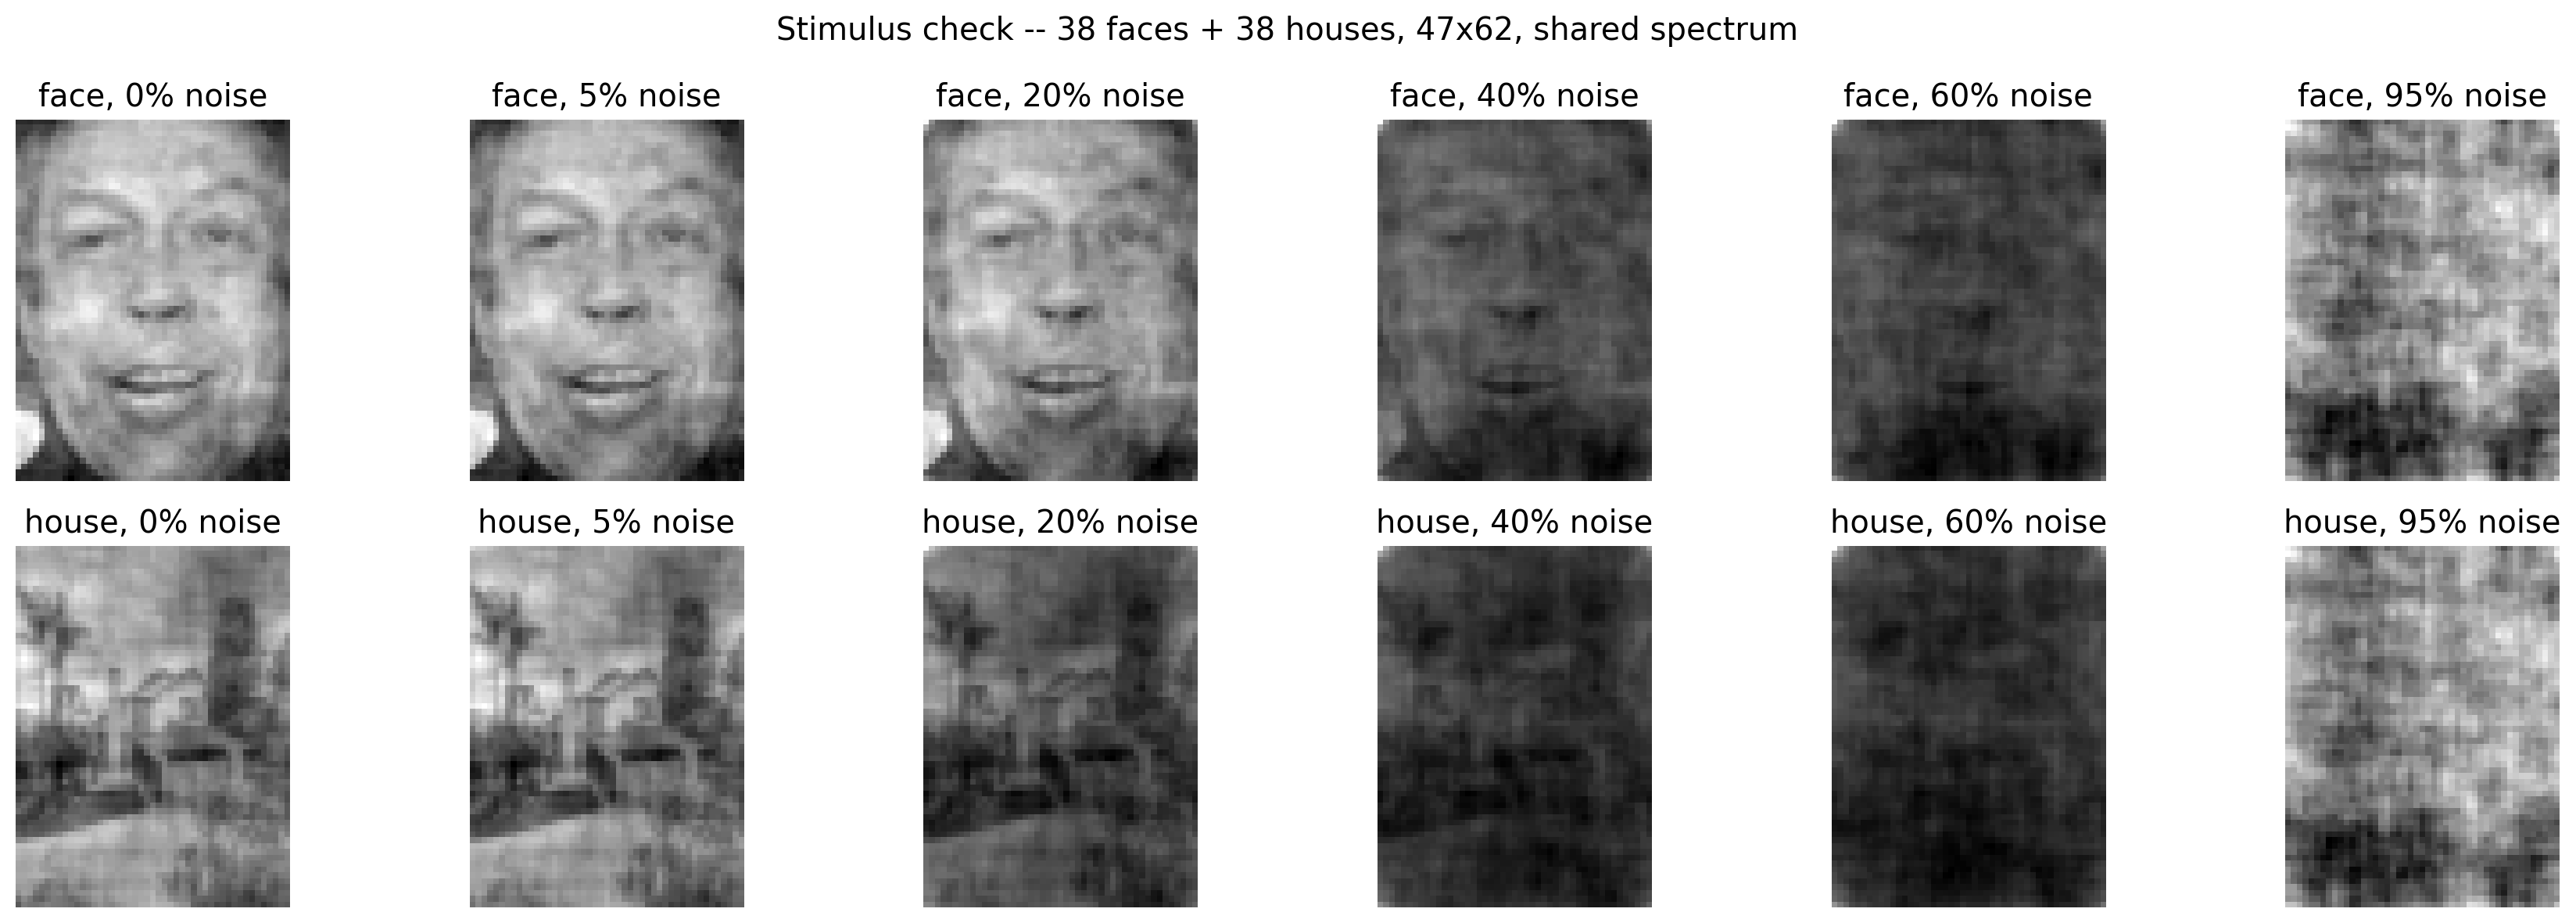

In [4]:
# @title Phase scrambling with a shared (category-independent) magnitude spectrum

noise_check = [0, 5, 20, 40, 60, 95]
fig, axes = plt.subplots(2, len(noise_check), figsize=(3*len(noise_check), 6))
for i, n in enumerate(noise_check):
    axes[0, i].imshow(phase_scramble(face_subset[0], n, avg_mag_all), cmap='gray')
    axes[0, i].set_title(f'face, {n}% noise'); axes[0, i].axis('off')
    axes[1, i].imshow(phase_scramble(house_subset[0], n, avg_mag_all), cmap='gray')
    axes[1, i].set_title(f'house, {n}% noise'); axes[1, i].axis('off')
plt.suptitle(f'Stimulus check -- {n_stim} faces + {n_stim} houses, {W}x{H}, shared spectrum')
plt.tight_layout(); display(Image(save_fig(fig, '01_stimulus_construction_fig01'))); plt.close(fig)


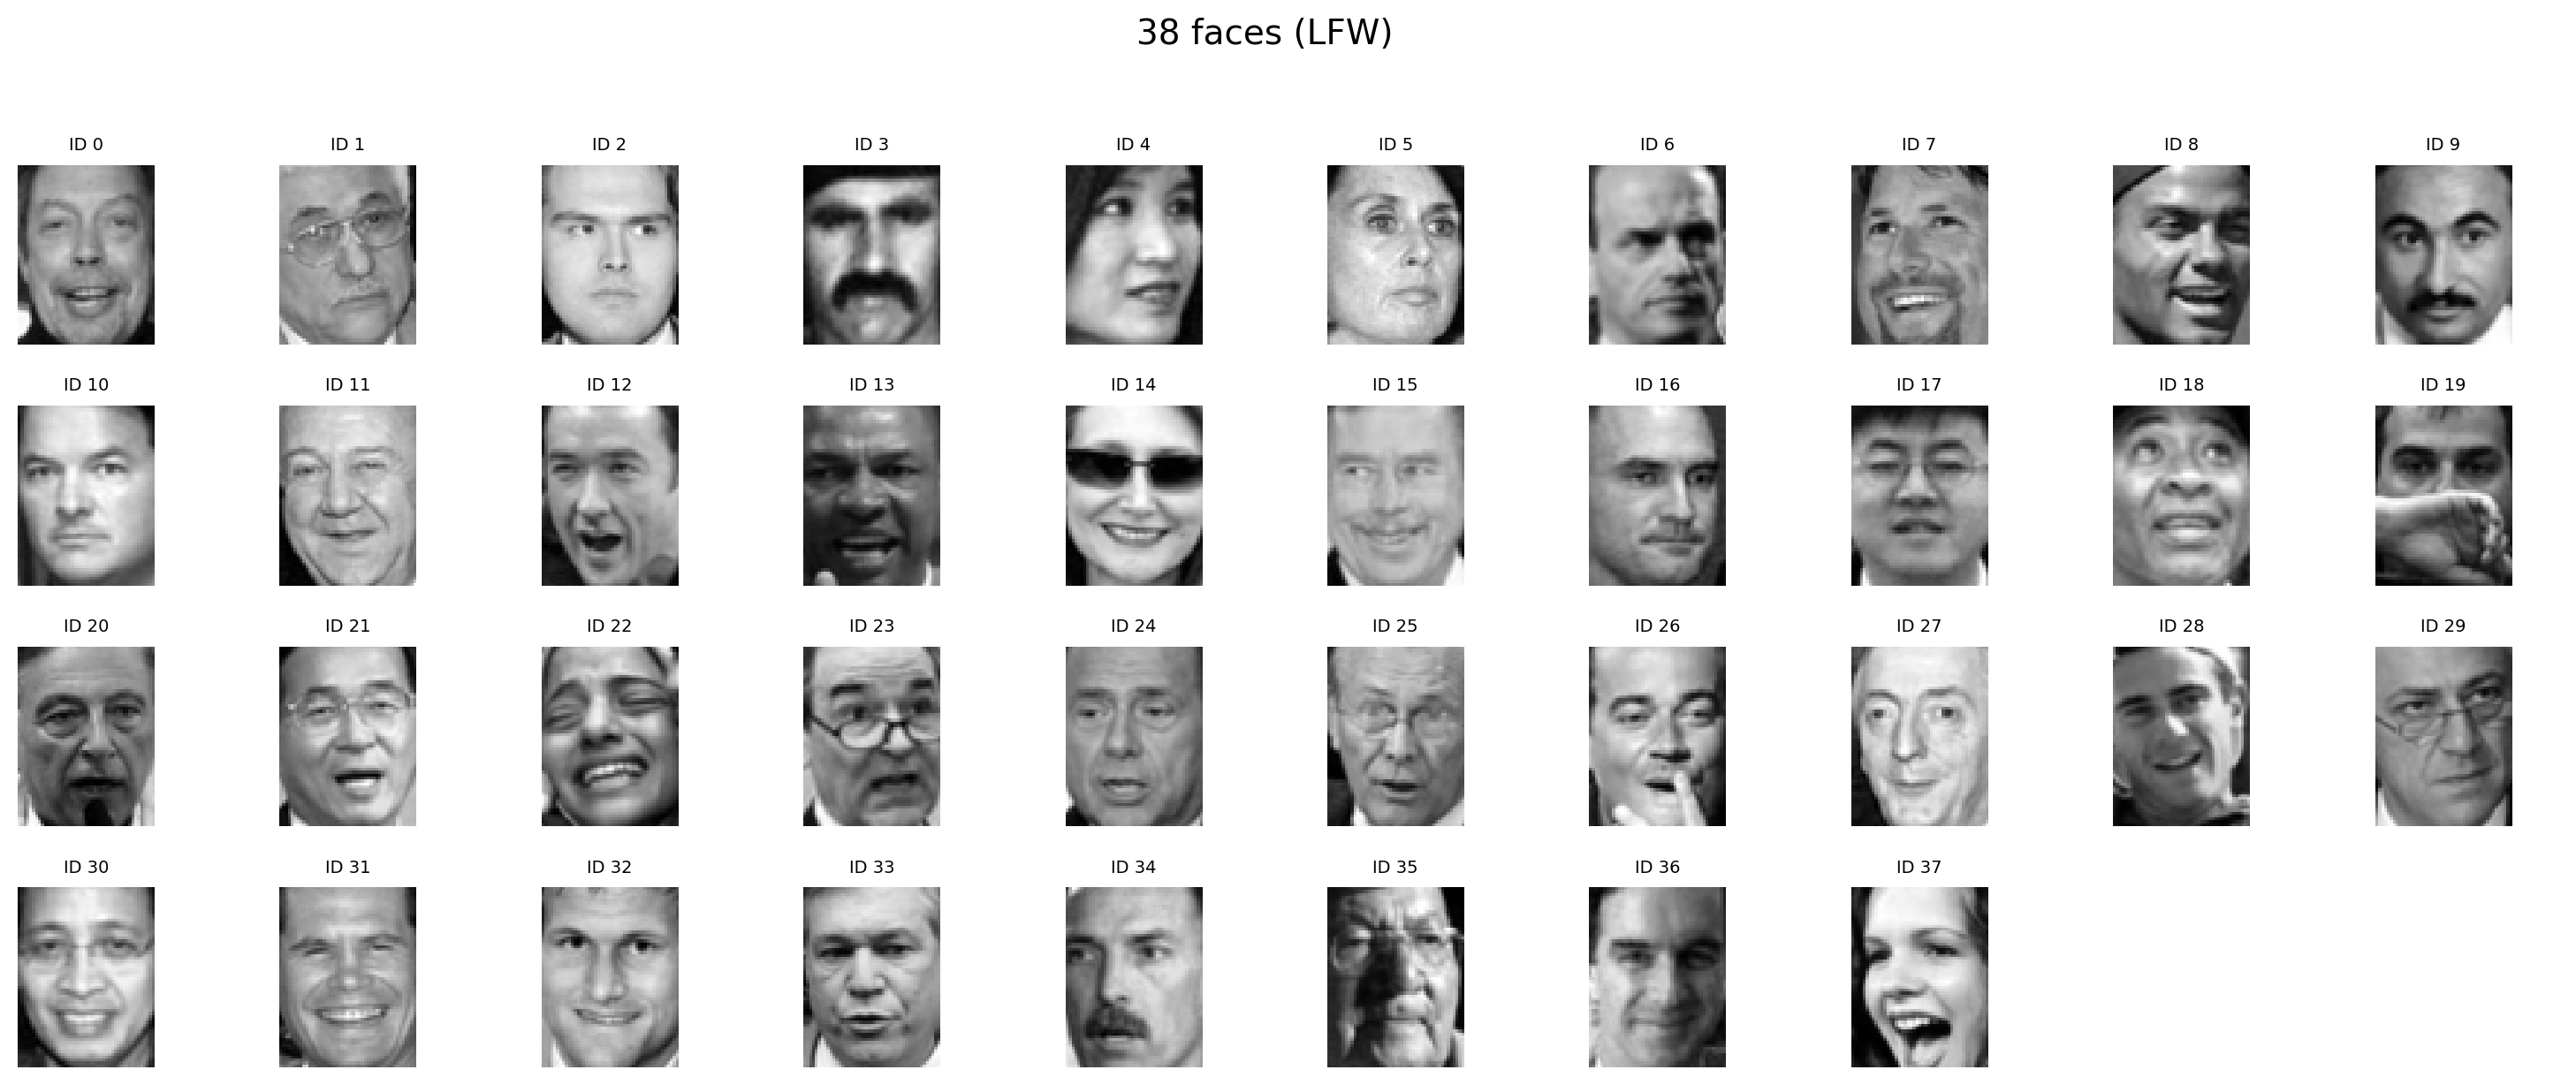

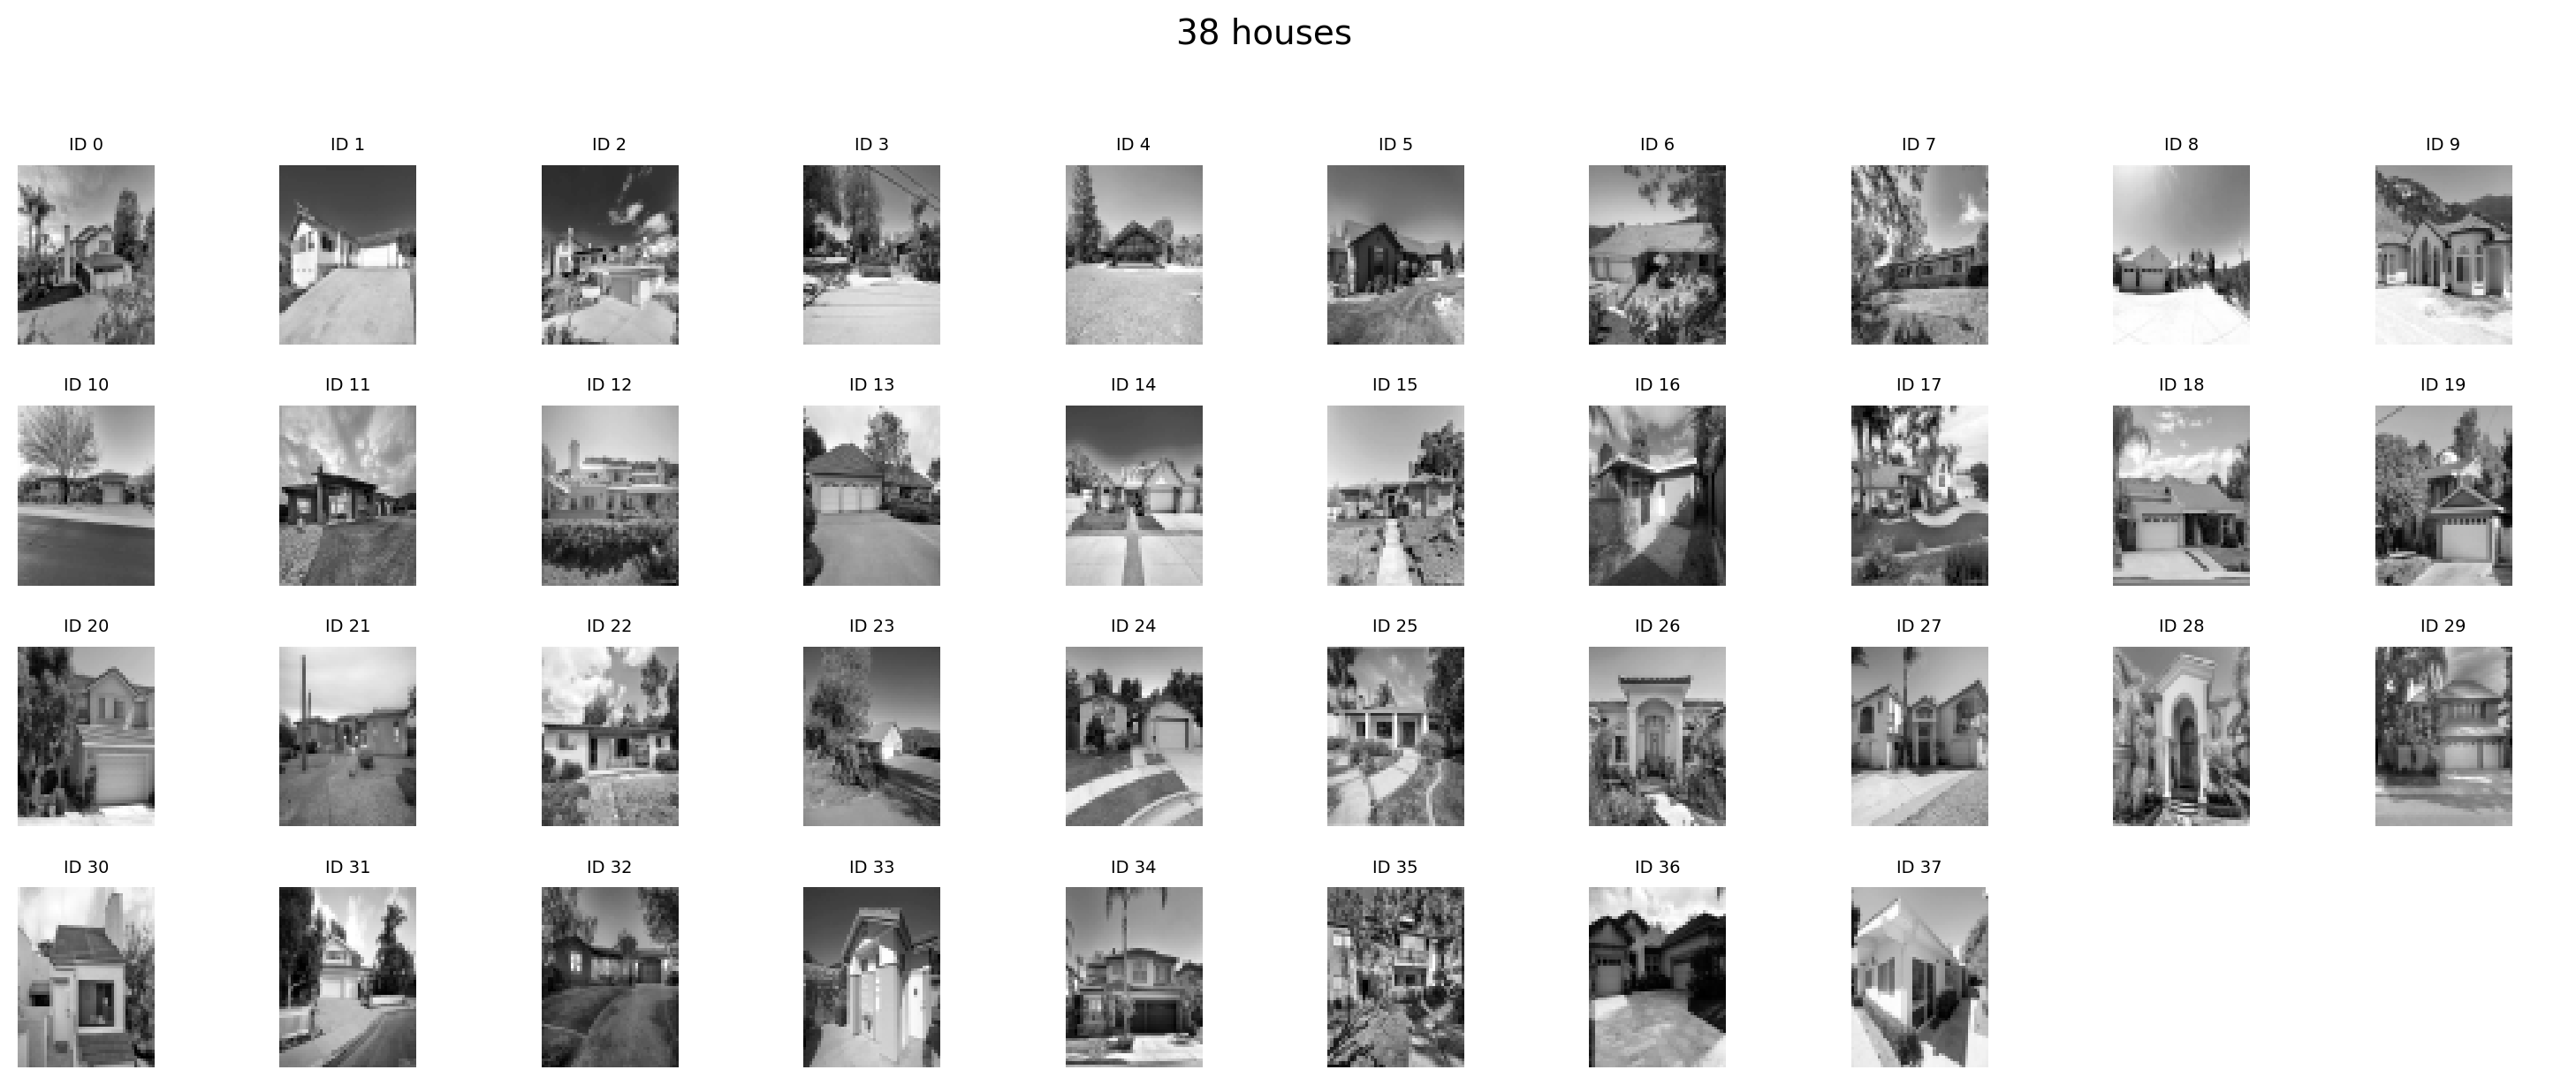

In [5]:
# @title Visualize the full stimulus inventory (38 faces, 38 houses)

def plot_full_subset(subset, title):
    n_total = len(subset); cols = 10; rows = (n_total // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(15, 1.5 * rows))
    fig.suptitle(title, fontsize=14, y=1.02)
    for i, ax in enumerate(axes.flat):
        if i < n_total:
            ax.imshow(subset[i], cmap='gray'); ax.set_title(f'ID {i}', fontsize=7)
        ax.axis('off')
    plt.tight_layout(); display(Image(save_fig(fig, '01_stimulus_construction_fig02'))); plt.close(fig)

plot_full_subset(face_subset, f'{n_stim} faces (LFW)')
plot_full_subset(house_subset, f'{n_stim} houses')


In [6]:
save_cache('01_stimulus_construction', face_subset=face_subset, house_subset=house_subset, avg_mag_all=avg_mag_all, W=W, H=H)


Cached ['face_subset', 'house_subset', 'avg_mag_all', 'W', 'H'] -> C:\Users\janak\GitHub\noisy-faces-brain-vs-cnn\cache\01_stimulus_construction.pkl


'C:\\Users\\janak\\GitHub\\noisy-faces-brain-vs-cnn\\cache\\01_stimulus_construction.pkl'